# Sequential Variational Autoencoders

In this lab we will build a very simple version of of [**LFADS: Latent Factor Analysis for Dynamical Systems**](https://www.nature.com/articles/s41592-018-0109-9) (Pandarinath et al, 2018). LFADS is a popular technique for for modeling neural spike train data, finding low-dimensional factors of variation, and studying their nonlinear dynamics. 

Technically, LFADS is a sequential variational autoencoder (VAE). Like all VAEs, it consists of two parts:
1. A **generative model** that can sample new sequences of latent variables and from them produce new spike trains.
2. An **encoder** that takes in spike trains and produces a distribution over latent variables that produced them.

In LFADS, both the generator and the encoder and implemented with **recurrent neural networks (RNNs)**. Once trained, we can study the dynamics learned by these RNNs and use the inputs necessary to drive them to produce realistic neural data.

**References**

- Pandarinath, Chethan, et al. "Inferring single-trial neural population dynamics using sequential auto-encoders." Nature methods 15.10 (2018): 805-815.

## LFADS architecture overview

LFADS extends a variational autoencoder from independent observations to complete neural time series. A bidirectional encoder maps the observed spike train $\mathbf{y}_{1:T}$ to two approximate posteriors: a trial-level initial state $q_{\phi}(\mathbf{x}_0\mid\mathbf{y}_{1:T})$ and time-varying inferred inputs $q_{\phi}(\mathbf{u}_{1:T}\mid\mathbf{y}_{1:T})$. Reparameterized samples drive a recurrent generator, whose states are mapped to nonnegative Poisson firing rates.

The training objective combines reconstruction fidelity with separate regularizers for the initial state and inferred inputs:

$$
\mathcal{L}_{\mathrm{LFADS}}
=
\mathbb{E}_{q_{\phi}}
\!\left[
\log p_{\theta}(\mathbf{y}_{1:T}\mid\mathbf{x}_0,\mathbf{u}_{1:T})
\right]
-D_{\mathrm{KL}}\!\left[q_{\phi}(\mathbf{x}_0)\,\|\,p(\mathbf{x}_0)\right]
-\sum_{t=1}^{T}D_{\mathrm{KL}}\!\left[q_{\phi}(\mathbf{u}_t)\,\|\,p(\mathbf{u}_t)\right].
$$

## Setup

In [ ]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import trange

# Register Conda's CUDA DLL directory on Windows before CUDA kernels are used.
_cuda_dll_handle = None
if os.name == "nt":
    _cuda_dll_dir = Path(sys.prefix) / "bin"
    if _cuda_dll_dir.is_dir():
        os.environ["PATH"] = str(_cuda_dll_dir) + os.pathsep + os.environ.get("PATH", "")
        _cuda_dll_handle = os.add_dll_directory(str(_cuda_dll_dir))

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal, Poisson, Uniform, kl_divergence
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import PCA
from scipy.linalg import sqrtm

## Part 0: Make some synthetic data

We'll start by simulating data from a simple oscillatory system with sparse "kicks" to the state. There are two underlying oscillators, $\theta_0$ and $\theta_1$, with different angular velocities (rates), $\dot{\theta}_0$ and $\dot{\theta}_1$. Each _trial_ starts in the same initial condition, $\theta_0 = \theta_1 = 0$, but then the oscillators receive random inputs $u_t \sim \mathrm{Unif}([0, 2 \pi))$. Importantly, both oscillators receive the same kicks! The resulting dynamics are,

$$
\theta_{d,t} = \theta_{d,t-1} + \dot{\theta}_d + u_t.
$$

for $d \in \{0,1\}$.

The neural spike trains are simulated as linear functions of the sine and cosine of the oscillators,

$$
\begin{align*}
y_{n,t} &\sim \mathrm{Po}(f(\mathbf{w}_n^\top \mathbf{x}_t + b_n)) \\
\mathbf{x}_t &= [\cos(\theta_0), \sin(\theta_0), \cos(\theta_1), \sin(\theta_1)]^\top. 
\end{align*}
$$

In [2]:
rate0 = 2 * torch.pi / 20.0
# rate1 = 1.4142 * 2 * torch.pi / 20.0
rate1 = 2 * rate0

def sample_trial(weights, bias,
                 num_timesteps=100,
                 rate0=rate0,
                 rate1=rate1,
                 kick_prob=0.05):
    """Sample a single trial of data according to the model above.
    """
    theta = torch.zeros(num_timesteps, 2)
    u = torch.zeros(num_timesteps, 1)
    for t in range(1, num_timesteps):
        if torch.rand(1) < kick_prob:
            u[t] = Uniform(0, 2 * torch.pi).sample()
        theta[t, 0] = theta[t-1, 0] + rate0 + u[t]
        theta[t, 1] = theta[t-1, 1] + rate1 + u[t]

    x = torch.column_stack([torch.cos(theta), torch.sin(theta)])
    y = Poisson(F.softplus(x @ weights.T + bias)).sample()
    return u, x, y

In [3]:
class OscillatorDataset(Dataset):
    """A dataset of randomly generated trials.
    """
    def __init__(self, num_neurons, num_timesteps, num_trials, seed=0):
        self.num_neurons = num_neurons
        self.num_timesteps = num_timesteps
        self.num_trials = num_trials

        # Sample random emission weights
        torch.manual_seed(seed)
        self.weights = torch.randn((num_neurons, 4))
        self.bias = torch.randn(num_neurons)

        # Permute based on read-out angle for \theta_1
        angle = torch.atan2(self.weights[:, 3], self.weights[:, 2])
        perm = torch.argsort(angle)
        self.weights = self.weights[perm]
        self.bias = self.bias[perm]

        # Sample trials
        all_trials = [sample_trial(self.weights, self.bias) for _ in range(num_trials)]
        self.all_inputs, self.all_states, self.all_spikes = list(zip(*all_trials))

    def __len__(self):
        return self.num_trials

    def __getitem__(self, idx):
        return dict(inputs=self.all_inputs[idx],
                    states=self.all_states[idx],
                    spikes=self.all_spikes[idx])

In [4]:
# Create the dataset
num_neurons = 100
num_timesteps = 100
num_trials = 1000

dataset = OscillatorDataset(num_neurons, num_timesteps, num_trials, seed=0)

Text(0, 0.5, 'spikes $y(t)$')

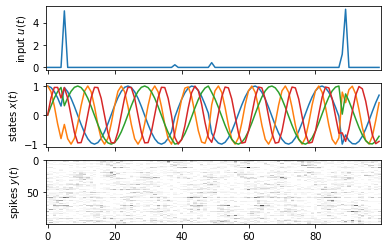

In [5]:
# Plot one trial
fig, axs = plt.subplots(3, 1, sharex=True)
trial = 2
axs[0].plot(dataset[trial]["inputs"])
axs[0].set_ylabel("input $u(t)$")
axs[1].plot(dataset[trial]["states"])
axs[1].set_ylabel("states $x(t)$")
axs[2].imshow(dataset[trial]["spikes"].T, 
              aspect="auto", interpolation="none", cmap="Greys")
axs[2].set_ylabel("spikes $y(t)$")

## Part 1: Recurrent Neural Networks in PyTorch

First, let's check out PyTorch's built-in recurrent neural network modules. Specifically, we will use a [**Gated Recurrent Unit (GRU)**](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html?highlight=gru#torch.nn.GRU). 

- Like other RNNs, a GRU takes in _inputs_ and an _initial state_ to produces a sequence of states. 
- The `nn.GRU` module allows for _stacks_ of GRU layers, so the initial state is really a tensor of initial states for all layers. The output states are just those of the last layer though.

**Note**: By default, `nn.GRU` modules assume the inputs are shape $(T,B,D)$ where $T$ is the number of time steps, $B$ is the batch size, and $D$ is the input dimension.

In [6]:
# Specify the size of the GRU and the daa
input_size = 1
hidden_size = 20
num_layers = 2
num_batches = 1

rnn = nn.GRU(input_size, hidden_size, num_layers)
init_state = torch.randn(num_layers, num_batches, hidden_size)
# inputs = torch.randn(num_timesteps, num_batches, input_size)
inputs = dataset[0]["inputs"][:, None, :] # add a batch dim

with torch.set_grad_enabled(False):
    states, final_state = rnn(inputs, init_state)

In [7]:
states.shape        # sequence of states from last layer

torch.Size([100, 1, 20])

In [8]:
final_state.shape   # final state of all layers

torch.Size([2, 1, 20])

(0.0, 99.0)

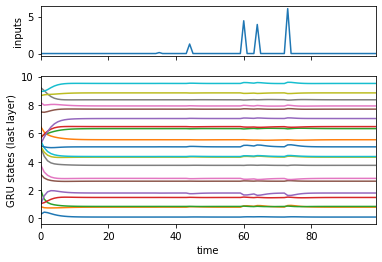

In [9]:
fig, axs = plt.subplots(2, 1, sharex=True, 
                        gridspec_kw=dict(height_ratios=[1, 3]))
axs[0].plot(inputs[:, 0, :])
axs[0].set_ylabel("inputs")
axs[1].plot(states[:, 0, :] + 0.5 * torch.arange(hidden_size))
axs[1].set_xlabel("time")
axs[1].set_ylabel("GRU states (last layer)")
axs[1].set_xlim(0, num_timesteps-1)

## Part 2: Building LFADS

Next, we construct an LFADS model. Once we've built it, we'll use it to estimate the latent oscillatory factors underlying our simulated data.

### Architecture of the sequential VAE

**Figure 1 | Information flow in the LFADS model implemented below.** The encoder reads the full spike sequence in both temporal directions. Its global head parameterizes the generator initial state, while its temporal head parameterizes one inferred input per time bin. Reparameterized samples drive the GRU generator. A linear readout followed by `softplus` defines Poisson firing rates. Dashed paths denote KL regularization toward standard normal priors.

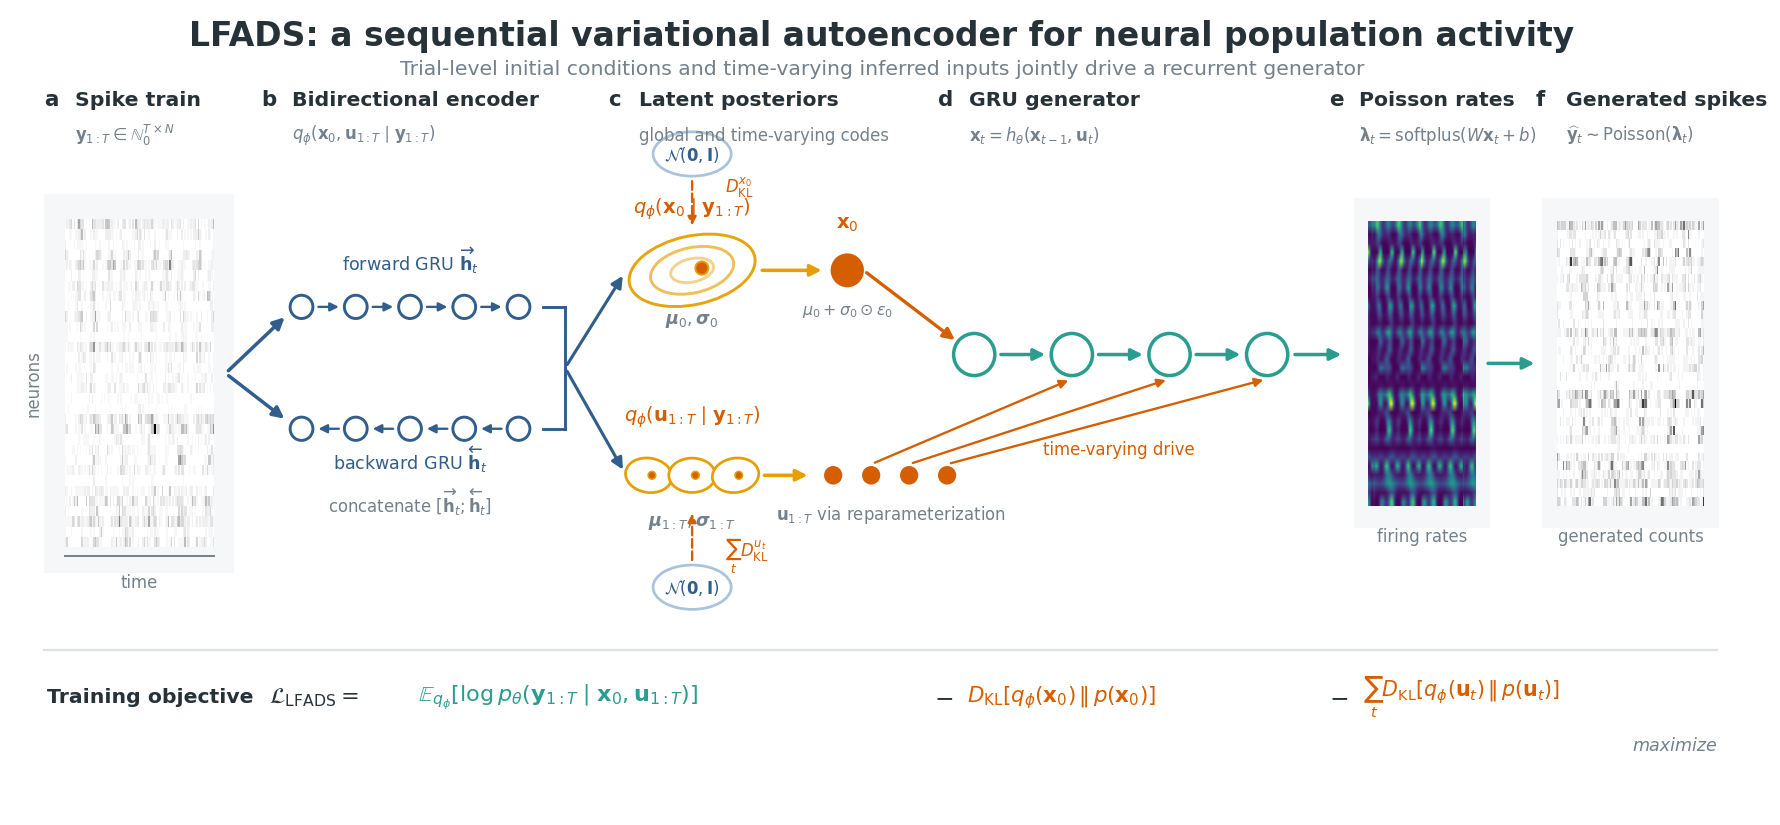

In [5]:
# Draw the LFADS architecture implemented in this notebook.
from matplotlib.patches import Circle, Ellipse, FancyArrowPatch, Rectangle

navy = "#315E8C"
navy_light = "#A9C3DA"
teal = "#2A9D8F"
teal_light = "#A8DCD5"
amber = "#E69F00"
orange = "#D55E00"
ink = "#263238"
muted = "#74818A"
grid = "#DCE3E7"
panel_bg = "#F5F7F8"

fig, ax = plt.subplots(figsize=(16, 7.4), dpi=140)
fig.patch.set_facecolor("white")
ax.set_xlim(0, 16)
ax.set_ylim(0, 7.2)
ax.axis("off")


def arrow(start, end, color=ink, width=1.6, style="-", mutation=12, rad=0.0):
    patch = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=mutation,
        linewidth=width,
        linestyle=style,
        color=color,
        connectionstyle=f"arc3,rad={rad}",
        shrinkA=2,
        shrinkB=2,
    )
    ax.add_patch(patch)
    return patch


def node(x, y, edge, radius=0.105, fill="white", lw=1.5):
    patch = Circle((x, y), radius, facecolor=fill, edgecolor=edge, linewidth=lw, zorder=5)
    ax.add_patch(patch)
    return patch


def panel_label(x, letter, title, subtitle=None):
    ax.text(x, 6.42, letter, fontsize=11, fontweight="bold", color=ink, va="center")
    ax.text(x + 0.28, 6.42, title, fontsize=10.5, fontweight="bold", color=ink, va="center")
    if subtitle:
        ax.text(x + 0.28, 6.10, subtitle, fontsize=8.5, color=muted, va="center")


# Title and subtitle
ax.text(
    8,
    7.00,
    "LFADS: a sequential variational autoencoder for neural population activity",
    ha="center",
    va="center",
    fontsize=17,
    fontweight="bold",
    color=ink,
)
ax.text(
    8,
    6.70,
    "Trial-level initial conditions and time-varying inferred inputs jointly drive a recurrent generator",
    ha="center",
    va="center",
    fontsize=10.5,
    color=muted,
)


# Panel a: observed spikes
panel_label(0.28, "a", "Spike train", r"$\mathbf{y}_{1:T}\in\mathbb{N}_0^{T\times N}$")
spikes = dataset[2]["spikes"][:, :32].T.detach().cpu().numpy()
ax.add_patch(Rectangle((0.28, 2.15), 1.75, 3.42, facecolor=panel_bg, edgecolor="none", zorder=0))
ax.imshow(
    spikes,
    extent=(0.47, 1.84, 2.38, 5.34),
    origin="lower",
    aspect="auto",
    cmap="Greys",
    interpolation="nearest",
    vmin=0,
    vmax=max(1, spikes.max()),
    zorder=2,
)
ax.plot([0.47, 1.84], [2.30, 2.30], color=muted, linewidth=1)
ax.text(1.15, 2.02, "time", ha="center", fontsize=8.5, color=muted)
ax.text(0.18, 3.86, "neurons", ha="center", va="center", rotation=90, fontsize=8.5, color=muted)


# Panel b: bidirectional encoder
panel_label(2.28, "b", "Bidirectional encoder", r"$q_{\phi}(\mathbf{x}_0,\mathbf{u}_{1:T}\mid\mathbf{y}_{1:T})$")
encoder_x = [2.65, 3.15, 3.65, 4.15, 4.65]
for i, x in enumerate(encoder_x):
    node(x, 4.55, navy, fill="white")
    node(x, 3.45, navy, fill="white")
    if i < len(encoder_x) - 1:
        arrow((x + 0.12, 4.55), (encoder_x[i + 1] - 0.12, 4.55), navy, 1.2, mutation=9)
        arrow((encoder_x[i + 1] - 0.12, 3.45), (x + 0.12, 3.45), navy, 1.2, mutation=9)
ax.text(3.65, 4.88, r"forward GRU $\overrightarrow{\mathbf{h}}_t$", ha="center", fontsize=9, color=navy)
ax.text(3.65, 3.08, r"backward GRU $\overleftarrow{\mathbf{h}}_t$", ha="center", fontsize=9, color=navy)
arrow((1.95, 3.95), (2.52, 4.48), navy, 1.8)
arrow((1.95, 3.95), (2.52, 3.52), navy, 1.8)
ax.plot([4.88, 5.08], [4.55, 4.55], color=navy, linewidth=1.5)
ax.plot([4.88, 5.08], [3.45, 3.45], color=navy, linewidth=1.5)
ax.plot([5.08, 5.08], [3.45, 4.55], color=navy, linewidth=1.5)
ax.text(3.65, 2.70, r"concatenate $[\overrightarrow{\mathbf{h}}_t;\overleftarrow{\mathbf{h}}_t]$", ha="center", fontsize=8.5, color=muted)


# Panel c: posterior heads and priors
panel_label(5.48, "c", "Latent posteriors", "global and time-varying codes")
arrow((5.08, 4.00), (5.63, 4.86), navy, 1.6)
arrow((5.08, 4.00), (5.63, 3.05), navy, 1.6)

# Global posterior q(x0)
for scale, alpha in ((1.0, 0.95), (0.66, 0.65), (0.34, 0.45)):
    ax.add_patch(Ellipse((6.25, 4.88), 1.18 * scale, 0.62 * scale, angle=12,
                         facecolor="none", edgecolor=amber, linewidth=1.5, alpha=alpha))
node(6.34, 4.90, amber, radius=0.06, fill=orange, lw=1.0)
ax.text(6.25, 5.40, r"$q_{\phi}(\mathbf{x}_0\mid\mathbf{y}_{1:T})$", ha="center", fontsize=10, color=orange)
ax.text(6.25, 4.40, r"$\boldsymbol{\mu}_0,\boldsymbol{\sigma}_0$", ha="center", fontsize=9, color=muted)

# Temporal posterior q(u_t)
u_centers = [5.85, 6.25, 6.65]
for i, x in enumerate(u_centers):
    ax.add_patch(Ellipse((x, 3.03), 0.43, 0.31, angle=(-8 + 8 * i),
                         facecolor="white", edgecolor=amber, linewidth=1.4))
    node(x + 0.03, 3.03, amber, radius=0.035, fill=orange, lw=0.8)
ax.text(6.25, 3.52, r"$q_{\phi}(\mathbf{u}_{1:T}\mid\mathbf{y}_{1:T})$", ha="center", fontsize=10, color=orange)
ax.text(6.25, 2.58, r"$\boldsymbol{\mu}_{1:T},\boldsymbol{\sigma}_{1:T}$", ha="center", fontsize=9, color=muted)

# Priors and KL paths
ax.add_patch(Ellipse((6.25, 5.93), 0.72, 0.40, facecolor="white", edgecolor=navy_light, linewidth=1.4))
ax.text(6.25, 5.93, r"$\mathcal{N}(\mathbf{0},\mathbf{I})$", ha="center", va="center", fontsize=8.5, color=navy)
arrow((6.25, 5.72), (6.25, 5.25), orange, 1.2, style="--", mutation=9)
ax.text(6.55, 5.58, r"$D_{\mathrm{KL}}^{x_0}$", fontsize=8.5, color=orange)
ax.add_patch(Ellipse((6.25, 2.02), 0.72, 0.40, facecolor="white", edgecolor=navy_light, linewidth=1.4))
ax.text(6.25, 2.02, r"$\mathcal{N}(\mathbf{0},\mathbf{I})$", ha="center", va="center", fontsize=8.5, color=navy)
arrow((6.25, 2.23), (6.25, 2.72), orange, 1.2, style="--", mutation=9)
ax.text(6.55, 2.30, r"$\sum_t D_{\mathrm{KL}}^{u_t}$", fontsize=8.5, color=orange)


# Reparameterized samples
arrow((6.86, 4.88), (7.48, 4.88), amber, 1.8)
node(7.68, 4.88, orange, radius=0.14, fill=orange)
ax.text(7.68, 5.26, r"$\mathbf{x}_0$", ha="center", fontsize=10, color=orange)
ax.text(7.68, 4.48, r"$\mu_0+\sigma_0\odot\epsilon_0$", ha="center", fontsize=8.2, color=muted)

arrow((6.88, 3.03), (7.35, 3.03), amber, 1.8)
sample_u_x = [7.55, 7.90, 8.25, 8.60]
for x in sample_u_x:
    node(x, 3.03, orange, radius=0.075, fill=orange, lw=1.0)
ax.text(8.08, 2.63, r"$\mathbf{u}_{1:T}$ via reparameterization", ha="center", fontsize=8.5, color=muted)


# Panel d: recurrent generator
panel_label(8.52, "d", "GRU generator", r"$\mathbf{x}_t=h_{\theta}(\mathbf{x}_{t-1},\mathbf{u}_t)$")
state_x = [8.85, 9.75, 10.65, 11.55]
for i, x in enumerate(state_x):
    node(x, 4.12, teal, radius=0.19, fill="white", lw=1.8)
    ax.text(x, 4.12, rf"$x_{{{i}}}$" if i < 3 else r"$x_T$", ha="center", va="center", fontsize=9, color=teal)
    if i < len(state_x) - 1:
        arrow((x + 0.21, 4.12), (state_x[i + 1] - 0.21, 4.12), teal, 1.8)
arrow((7.83, 4.88), (8.70, 4.23), orange, 1.7)
for i, x in enumerate(state_x[1:]):
    source_x = sample_u_x[min(i + 1, len(sample_u_x) - 1)]
    arrow((source_x, 3.13), (x, 3.90), orange, 1.2, mutation=9)
ax.text(10.18, 3.22, "time-varying drive", ha="center", fontsize=8.5, color=orange)


# Panel e: emission model
panel_label(12.12, "e", "Poisson rates", r"$\boldsymbol{\lambda}_t=\operatorname{softplus}(W\mathbf{x}_t+b)$")
arrow((11.77, 4.12), (12.27, 4.12), teal, 1.8)
rate_map = F.softplus(
    dataset[2]["states"] @ dataset.weights.T + dataset.bias
)[:, :32].T.detach().cpu().numpy()
ax.add_patch(Rectangle((12.35, 2.55), 1.25, 2.98, facecolor=panel_bg, edgecolor="none", zorder=0))
ax.imshow(
    rate_map,
    extent=(12.48, 13.47, 2.75, 5.32),
    origin="lower",
    aspect="auto",
    cmap="viridis",
    interpolation="bilinear",
    zorder=2,
)
ax.text(12.98, 2.43, "firing rates", ha="center", fontsize=8.5, color=muted)


# Panel f: reconstructed spikes
panel_label(14.02, "f", "Generated spikes", r"$\widehat{\mathbf{y}}_t\sim\operatorname{Poisson}(\boldsymbol{\lambda}_t)$")
arrow((13.55, 4.04), (14.05, 4.04), teal, 1.8)
reconstruction = np.random.default_rng(4).poisson(rate_map)
ax.add_patch(Rectangle((14.08, 2.55), 1.63, 2.98, facecolor=panel_bg, edgecolor="none", zorder=0))
ax.imshow(
    reconstruction,
    extent=(14.22, 15.57, 2.75, 5.32),
    origin="lower",
    aspect="auto",
    cmap="Greys",
    interpolation="nearest",
    vmin=0,
    vmax=max(1, reconstruction.max()),
    zorder=2,
)
ax.text(14.90, 2.43, "generated counts", ha="center", fontsize=8.5, color=muted)


# ELBO strip
ax.plot([0.28, 15.70], [1.45, 1.45], color=grid, linewidth=1.2)
ax.text(0.30, 1.03, "Training objective", fontsize=10.5, fontweight="bold", color=ink, va="center")
ax.text(
    2.35,
    1.03,
    r"$\mathcal{L}_{\mathrm{LFADS}}=$",
    fontsize=11.5,
    color=ink,
    va="center",
)
ax.text(
    3.72,
    1.03,
    r"$\mathbb{E}_{q_{\phi}}[\log p_{\theta}(\mathbf{y}_{1:T}\mid\mathbf{x}_0,\mathbf{u}_{1:T})]$",
    fontsize=11.5,
    color=teal,
    va="center",
)
ax.text(8.48, 1.03, r"$-$", fontsize=12, color=ink, va="center")
ax.text(8.78, 1.03, r"$D_{\mathrm{KL}}[q_{\phi}(\mathbf{x}_0)\,\|\,p(\mathbf{x}_0)]$", fontsize=11, color=orange, va="center")
ax.text(12.12, 1.03, r"$-$", fontsize=12, color=ink, va="center")
ax.text(12.43, 1.03, r"$\sum_t D_{\mathrm{KL}}[q_{\phi}(\mathbf{u}_t)\,\|\,p(\mathbf{u}_t)]$", fontsize=10.6, color=orange, va="center")
ax.text(15.70, 0.55, "maximize", ha="right", fontsize=9, color=muted, style="italic")

plt.show()

### Part 2a: Generative model

The LFADS generative model consists of two parts: inputs $\mathbf{u}_t$ and states $\mathbf{x}_t$. The state at time $t$ is a deterministic function of the previous state, the input, and the RNN weights $\theta_{\mathsf{RNN}}$,

$$
\mathbf{x}_t = h(\mathbf{x}_{t-1}, \mathbf{u}_t; \theta_{\mathsf{RNN}})
$$

Here, $h$ is a GRU. 

To sample a new sequence of latent states, we randomly sample an initial condition $\mathbf{x}_0$ and a sequence of inputs, then pass them through the RNN,

1. Sample initial condition and inputs,
    
   $$
   \begin{align*}
   \mathbf{x}_0 &\sim \mathcal{N}(0, \mathbf{I}) \\
   \mathbf{u}_t &\overset{\mathsf{iid}}{\sim} \mathcal{N}(0, \mathbf{I}) & \text{for } t &=1, \ldots, T
   \end{align*}
   $$

   and apply the RNN to get $\mathbf{x}_{1:T}$.

2. Pass the states$^*$  through a GLM to get firing rates, then sample spike counts,

   $$
   y_{t,n} \sim \mathrm{Po}(f(\mathbf{w}_n^\top \mathbf{x}_t + b_n))
   $$

   where $f$ is a rectifying nonlinearity, like the softplus or exponential funciton.

$^*$ Technically, just the states from the last layer of the GRU.

In [10]:
class LFADSGenerator(nn.Module):
    def __init__(self, 
                 num_neurons,
                 input_size,
                 num_timesteps,
                 hidden_size=20,
                 num_layers=2):
        
        super(LFADSGenerator, self).__init__()
        
        # Initialize the layer
        self.rnn = nn.GRU(input_size, hidden_size, num_layers)
        self.linear = nn.Linear(hidden_size, num_neurons)
        
    def forward(self, initial_state, inputs):
        """
        initial_state: (num_layers, num_batches, hidden_size) initial state
        inputs: (num_timesteps, num_batches, input_size) tensor of inputs
        
        returns: Poisson distribution with rates of shape
            (num_timesteps, num_batches, num_neurons), 
            along with the RNN states.
        """
        # cuDNN RNN kernels require contiguous inputs and hidden states.
        states, _ = self.rnn(inputs.contiguous(), initial_state.contiguous())
        rates = F.softplus(self.linear(states))
        return Poisson(rates), states

Text(0, 0.5, 'spikes $y(t)$')

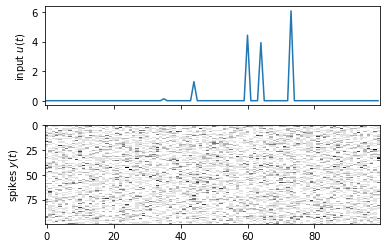

In [11]:
generator = LFADSGenerator(num_neurons=num_neurons,
                           input_size=1,
                           num_timesteps=num_timesteps,
                           hidden_size=10,
                           num_layers=1) 

# Sample spikes from the untrained generator
init_state = torch.randn((1, 1, 10))
init_lkhd, _ = generator(init_state, 20 * dataset[0]["inputs"][:, None, :])
init_spikes = init_lkhd.sample()

fig, axs = plt.subplots(2, 1, sharex=True)
axs[0].plot(dataset[0]["inputs"])
axs[0].set_ylabel("input $u(t)$")
axs[1].imshow(init_spikes[:, 0, :].T, aspect="auto", interpolation="none", cmap="Greys")
axs[1].set_ylabel("spikes $y(t)$")

### Part 2b: Encoder

The LFADS encoder takes in a spike train and produces a **variational posterior** distribution over the initial condition and inputs. In our implementation, we will model the posteriors as Gaussian distributions,

$$
\begin{align*}
q(\mathbf{x}_0) &= \mathcal{N}(\tilde{\boldsymbol{\mu}}_0, \tilde{\boldsymbol{\Sigma}}_0) \\
q(\mathbf{u}_t) &= \mathcal{N}(\tilde{\boldsymbol{\mu}}_t, \tilde{\boldsymbol{\Sigma}}_t)
\end{align*}
$$

**Note**: The mean $\tilde{\boldsymbol{\mu}}_0$ is not the same dimension as the other means $\tilde{\boldsymbol{\mu}}_t$ since $\mathbf{x}_0$ and $\mathbf{u}_t$ are different sizes. Same for the covariances.

The encoder **amortizes** the inference computation by learning an RNN with weights $\phi$ that can take in a spike train $\mathbf{y}_{1:T}$ and produce approximate posterior parameters $\tilde{\boldsymbol{\mu}}_{0:T}$ and $\tilde{\boldsymbol{\Sigma}}_{0:T}$, It does so via a **bidirectional** RNN: it runs a GRU both forward and backward over the data to produce an combined RNN state, which it then maps to parameters.

In [12]:
class LFADSEncoder(nn.Module):
    def __init__(self, 
                 num_neurons=20,
                 input_size=2,
                 num_timesteps=100,
                 gen_hidden_size=20,
                 gen_num_layers=2,
                 enc_hidden_size=20,
                 enc_num_layers=2):
        super(LFADSEncoder, self).__init__()
        self.num_neurons = num_neurons
        self.input_size = input_size
        self.num_timesteps = num_timesteps
        self.gen_hidden_size = gen_hidden_size
        self.gen_num_layers = gen_num_layers
        self.enc_hidden_size = enc_hidden_size
        self.enc_num_layers = enc_num_layers
        
        # Initialize the bidirection encoder GRU
        self.birnn = nn.GRU(num_neurons, enc_hidden_size, enc_num_layers, bidirectional=True)

        # Treat the initial state of the BiRNN as a learnable variational parameter
        self.init_birnn_state = nn.Parameter(torch.zeros((2 * enc_num_layers, 1, enc_hidden_size)))
        
        # Initialize linear layer for the initial state mean and var
        self.W_init_mean = nn.Linear(2 * enc_hidden_size, 
                                     gen_num_layers * gen_hidden_size)
        self.W_init_std = nn.Linear(2 * enc_hidden_size, 
                                    gen_num_layers * gen_hidden_size)
        self.W_input_mean = nn.Linear(2 * enc_hidden_size, input_size)
        self.W_input_std = nn.Linear(2 * enc_hidden_size, input_size)

    def forward(self, spikes):
        """
        spikes: (num_timesteps, num_batches, num_neurons) tensor of inputs
        returns: 
            init_dist: q(x_0), a Normal distribution
            input_dist: q(u_{1:T}), a Normal distribution
        """
        assert spikes.ndim == 3
        assert spikes.shape[0] == self.num_timesteps
        assert spikes.shape[2] == self.num_neurons
        num_batches = spikes.shape[1]

        # Run the encoder BiRNN to get states
        # states: (num_timesteps, num_batches, 2 * enc_hidden_size)
        init_birnn_state = torch.tile(self.init_birnn_state, (1, num_batches, 1))
        states, _ = self.birnn(spikes, init_birnn_state) 

        # Decode the initial state distribution (num_batches, state_size)
        # where state_size = gen_num_layers * gen_hidden_size
        init_mean = self.W_init_mean(states[0])
        init_std = F.softplus(self.W_init_std(states[0]))

        # We need to reshape the intial mean and std into the desired shape
        def _reshape(x):
            x = x.reshape(num_batches, self.gen_num_layers, self.gen_hidden_size)
            x = x.permute((1, 0, 2)).contiguous()
            return x
        init_dist = Normal(_reshape(init_mean), _reshape(init_std))

        # Decode the input distribution (num_timesteps, num_batches, input_size)
        input_mean = self.W_input_mean(states)
        input_std = F.softplus(self.W_input_std(states))
        input_dist = Normal(input_mean, input_std)

        return init_dist, input_dist

In [13]:
encoder = LFADSEncoder(num_neurons=num_neurons,
                       input_size=1,
                       num_timesteps=num_timesteps,
                       gen_hidden_size=10,
                       gen_num_layers=1)

In [14]:
# Make sure it runs
encoder(dataset[0]["spikes"][:, None, :])

(Normal(loc: torch.Size([1, 1, 10]), scale: torch.Size([1, 1, 10])),
 Normal(loc: torch.Size([100, 1, 1]), scale: torch.Size([100, 1, 1])))

### Part 2c: The combined LFADS model

Now that we've implemented the generative model and encoder, all that's left is to stick them together! The `LFADS` module below does exactly that. Its `forward` function takes in a spike train, passes it through the encoder to obtain a posterior distribution over initial condition and inputs, samples the posterior, and passes the result through the generator to obtain reconstructed firing rates. 

**Note:** It's important to use `rsample` to sample the variational posteriors using the **reparameterization trick**!

In [15]:
class LFADS(nn.Module):
    """LFADS is a sequential VAE with a generative model and an encoder.
    """
    def __init__(self,
                 num_neurons=20,
                 input_size=2,
                 num_timesteps=100,
                 gen_hidden_size=20,
                 gen_num_layers=2,
                 enc_hidden_size=25,
                 enc_num_layers=2):
        super(LFADS, self).__init__()
        self.num_neurons = num_neurons
        self.input_size = input_size
        self.num_timesteps = num_timesteps
        self.gen_hidden_size = gen_hidden_size
        self.gen_num_layers = gen_num_layers
        self.enc_hidden_size = enc_hidden_size
        self.enc_num_layers = enc_num_layers

        # Construct the generative model and encoder
        self.generator = LFADSGenerator(num_neurons,
                                        input_size,
                                        num_timesteps,
                                        gen_hidden_size,
                                        gen_num_layers)
        
        self.encoder = LFADSEncoder(num_neurons,
                                    input_size,
                                    num_timesteps,
                                    gen_hidden_size,
                                    gen_num_layers,
                                    enc_hidden_size,
                                    enc_num_layers)
        
    def forward(self, spikes):
        """Run the encoder to get a posterior distribution,
        then sample the posterior and pass it through the 
        generator to reconstruct the spikes.
        """
        # Compute the posterior
        q_x0, q_u = self.encoder(spikes)

        # Sample the posterior. 
        # NOTE: Use `rsample` to ensure resampling gradients work
        x0 = q_x0.rsample()
        u = q_u.rsample()

        # Reconstruct with the generator
        p_y, x = self.generator(x0, u)
        return p_y, q_x0, q_u, x
        

### Part 2d: Implement the ELBO objective

Finally, implement the ELBO,

$$
\begin{multline*}
\mathcal{L}(\theta, \phi) =
\mathbb{E}_{q_\phi(\mathbf{x}_0) q_\phi(\mathbf{u}_{1:T})} \left[ \log p_\theta(\mathbf{y}_{1:T} \mid \mathbf{x}_0, \mathbf{u}_{1:T}) \right] \\
- \mathrm{KL}(q_\phi(\mathbf{x}_0) \,\|\, p_\theta(\mathbf{x}_0)) - \sum_{t=1}^T \mathrm{KL}(q_\phi(\mathbf{u}_t) \,\|\, p_\theta(\mathbf{u}_t))
\end{multline*}
$$

In [16]:
def elbo(spikes, model):
    p_y, q_x0, q_u, _ = model(spikes)
    L = p_y.log_prob(spikes).sum()
    L -= kl_divergence(q_x0, Normal(0, 1)).sum()
    L -= kl_divergence(q_u, Normal(0, 1)).sum()
    return L


def objective(minibatch, model):
    """Compute the average negative elbo. 
    Make sure model and data are on the GPU.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    spikes = minibatch["spikes"].permute(1, 0, 2).to(device)
    return -elbo(spikes, model) / spikes.numel()

In [17]:
# Make sure the code at least runs
dataloader = DataLoader(dataset, batch_size=1)
lfads = LFADS(num_neurons=num_neurons,
              input_size=1,
              num_timesteps=num_timesteps,
              gen_hidden_size=10,
              gen_num_layers=2)
objective(next(iter(dataloader)), lfads)

tensor(1.6627, device='cuda:0', grad_fn=<DivBackward0>)

## Part 3: Fit it!

First, we've written a simple function to fit the model.

In [18]:
def train_model(model, 
                dataloader, 
                objective,
                num_epochs, 
                lr=0.001):
    """Helper function to fit a model.
    """
    # progress bars
    pbar = trange(num_epochs)
    pbar.set_description("Epoch")
    inner_pbar = trange(len(dataloader))
    inner_pbar.set_description("Loss")
    
    # use standard SGD with a decaying learning rate
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Track the train and validation loss
    losses = []
    for epoch in range(num_epochs):
        model.train()
        inner_pbar.reset()
            
        # track the running loss over batches
        for minibatch in dataloader:
            
            with torch.set_grad_enabled(True):
                optimizer.zero_grad()
                # compute the model output and loss
                loss = objective(minibatch, model)
                
                # take the gradient and perform an sgd step
                loss.backward()
                optimizer.step()
            
            # Update running loss
            losses.append(loss)
            inner_pbar.set_description("Loss {:.4f}".format(loss))
            inner_pbar.update(1)

        # Update the progress bar
        pbar.update(1)

    return torch.tensor(losses)

In [19]:
# Run the train function.
torch.manual_seed(0)
dataloader = DataLoader(dataset, batch_size=1)
lfads = LFADS(num_neurons=num_neurons,
              input_size=1,
              num_timesteps=num_timesteps,
              gen_hidden_size=10,
              gen_num_layers=2)
lfads.to("cuda")
losses = train_model(lfads, dataloader, objective, num_epochs=20)

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Text(0, 0.5, 'Loss (Avg. Negative ELBO)')

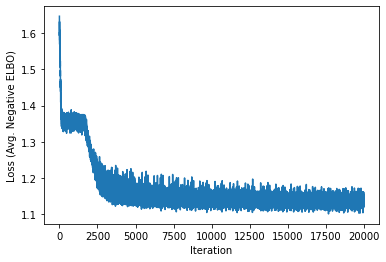

In [20]:
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss (Avg. Negative ELBO)")

### Part 3a: Reconstruct firing rates

As a first check, let's see if the model has learned to reconstruct the firing rates. 

In [21]:
# Reconstruct a single trial
lfads.to("cpu")
spikes = dataset[0]["spikes"]
true_inputs = dataset[0]["inputs"]

with torch.set_grad_enabled(False):
    p_y, q_x0, q_u, xs = lfads(spikes[:, None, :])

vmax = max(spikes.max(), p_y.rate.max())

Text(0.5, 1.0, 'reconstructed firing rates')

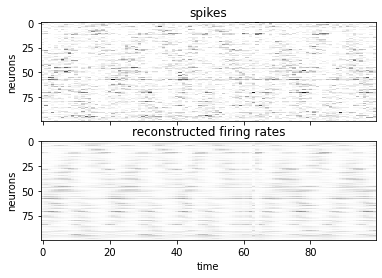

In [22]:
fig, axs = plt.subplots(2, 1, sharex=True)
axs[0].imshow(spikes.T, aspect="auto", interpolation="none", 
              cmap="Greys", vmin=0, vmax=vmax)
axs[0].set_ylabel("neurons")
axs[0].set_title("spikes")
axs[1].imshow(p_y.rate[:, 0, :].T, aspect="auto", interpolation="none", 
              cmap="Greys", vmin=0, vmax=vmax)
axs[1].set_ylabel("neurons")
axs[1].set_xlabel("time")
axs[1].set_title("reconstructed firing rates")

### Part 3b: Simulate from the learned model

The reconstructions above were based on **inferred inputs**. To see if the model has truly learned the oscillatory dynamics of this synthetic data, let's simulate from the model with zero inputs. We'll start it with a sample from the initial distribution output by the encoder.

Text(0.5, 1.0, 'reconstructed firing rates')

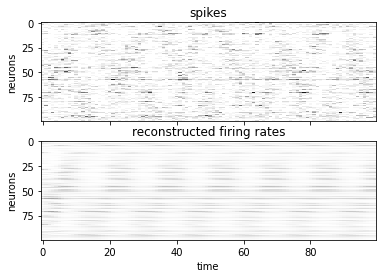

In [23]:
# Run the LFADS generator forward with zero inputs
with torch.set_grad_enabled(False):
    x0 = q_x0.mean
    inputs = torch.zeros_like(q_u.mean)
    lkhd, xs = lfads.generator(x0, inputs)
    xs = xs[:, 0, :]
    rates = lkhd.mean[:, 0, :]

fig, axs = plt.subplots(2, 1, sharex=True)
axs[0].imshow(spikes.T, aspect="auto", interpolation="none", 
              cmap="Greys", vmin=0, vmax=vmax)
axs[0].set_ylabel("neurons")
axs[0].set_title("spikes")
axs[1].imshow(rates.T, aspect="auto", interpolation="none", 
              cmap="Greys", vmin=0, vmax=vmax)
axs[1].set_ylabel("neurons")
axs[1].set_xlabel("time")
axs[1].set_title("reconstructed firing rates")

It looks like the model has learned to produce some oscillatory dynamics, but they decay to zero over time. That probably means the model is compensating by learning inputs that can sustain the oscillations. Let's check out the inferred inputs.

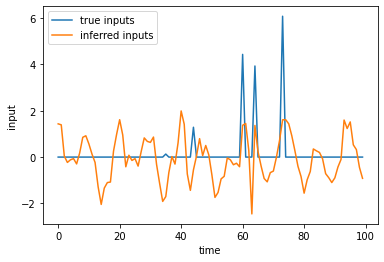

In [24]:
plt.plot(true_inputs, label="true inputs")
plt.plot(q_u.mean[:, 0, 0], label="inferred inputs")
plt.xlabel("time")
plt.ylabel("input")
plt.legend()

Indeed, it looks like the encoder produces large input spikes at times when the true inputs are present, but it also has oscillatory dynamics throughout the trial that really should have been captured by the RNN.

**Question:** What does this finding suggest about how you should interpret the inferred inputs?

### Part 3c: Looking at the inferred states

In LFADS, the firing rates are rectified linear functions of the underlying RNN states. We can get a sense for how high-dimensional those states are by looking at the SVD of the output weights. 

Text(0, 0.5, 'singular value')

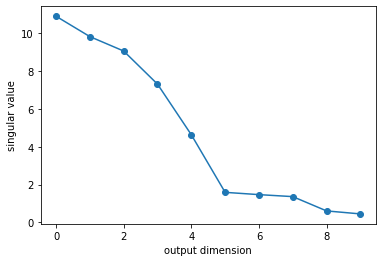

In [25]:
with torch.set_grad_enabled(False):
    U, S, Vh = torch.linalg.svd(lfads.generator.linear.weight)

plt.plot(S, '-o')
plt.xlabel("output dimension")
plt.ylabel("singular value")

Indeed, it looks like the model has learned that firing rates are low dimensional. Only 5 singular values stand out from the rest. In this synthetic data, recall that the firing rates are truly 4 dimensional (they are linear functions of the sine and cosine of two oscillators). The model isn't far off!

Next, let's plot the generated RNN states projected onto these 5 **output dimensions**.

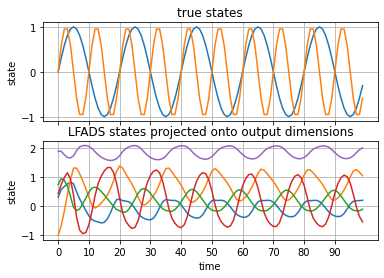

In [30]:
xs_proj = xs @ Vh[:5].T
fig, axs = plt.subplots(2, 1, sharex=True)
ts = torch.arange(num_timesteps)
axs[0].plot(ts, torch.sin(rate0 * ts))
axs[0].plot(ts, torch.sin(rate1 * ts))
axs[0].set_ylabel("state")
axs[0].set_title("true states")
axs[0].grid(True)

axs[1].plot(xs_proj)
axs[1].set_xlabel("time")
axs[1].set_xticks(torch.arange(0, num_timesteps, 10))
axs[1].set_ylabel("state")
axs[1].set_title("LFADS states projected onto output dimensions")
axs[1].grid(True)

These seem to have captured some oscillations! It's not so obvious they're the right frequencies, but close...ish.

## Part 7: Conclusion and Future Directions

### What We Learned

In this notebook, we implemented a simplified version of LFADS that demonstrates the core principles of using sequential variational autoencoders to discover latent dynamics in neural population recordings. The key components are:

1. **Bidirectional Encoder**: Processes the entire spike train to infer posterior distributions over initial conditions and external inputs
2. **Generative RNN**: Evolves latent states through learned nonlinear dynamics
3. **Poisson Decoder**: Maps latent states to spike rates via a GLM
4. **ELBO Objective**: Balances reconstruction accuracy with posterior regularization

### Analysis Methods Demonstrated

- **Reconstruction quality**: Comparing observed vs. inferred spike rates
- **Dimensionality reduction**: SVD and PCA to understand latent structure
- **Phase portraits**: Vector field analysis to visualize learned dynamics
- **Lyapunov exponents**: Characterizing stability and chaos in dynamics
- **Generalization**: Evaluating performance on held-out test data
- **Ground truth comparison**: Validating learned factors with known structure

### Advanced Topics Covered

- Multiple seeds to assess robustness of learned representations
- Model diagnostics including KL divergence and log-likelihood decomposition
- Sensitivity analysis for hyperparameter selection
- Comparison between learned and true dynamics in synthetic data

### Practical Considerations

The simplified LFADS presented here captures the essence of the method but omits some important features of the full implementation:

- **Refractory period modeling**: Explicit modeling of neuron refractory periods
- **Co-dimension reduction**: Sequentially reducing dimensions during training
- **Output regularization**: L2 penalties on readout weights
- **Variational dropout**: Stochastic regularization in RNNs
- **Scheduled sampling**: Curriculum learning for better training

### Future Extensions

For real neural data, you might consider:

1. **Conditional modeling**: Include behavioral variables, stimuli, or task structure
2. **Multi-population analysis**: Separate shared vs. population-specific factors
3. **Switching dynamics**: Model context-dependent changes in dynamics rules
4. **Uncertainty quantification**: Sample from posteriors to assess inference confidence
5. **Integration with theory**: Compare learned dynamics with mechanistic circuit models

### References

- Pandarinath, C., et al. (2018). "Inferring single-trial neural population dynamics using sequential auto-encoders." Nature Methods, 15(10), 805-815.
- Vyas, S., et al. (2020). "Computation through neural population dynamics." Annual Review of Neuroscience, 43, 249-275.
- Sussillo, D., & Barak, O. (2013). "Opening the black box of Neural Networks: methods for interpreting neural network models." Nature Reviews Neuroscience, 16(11), 763-818.


In [ ]:
# Hyperparameter sensitivity analysis (optional - commented out as it's expensive)
# Uncomment to run

# Test sensitivity to hidden dimension
hidden_dims = [5, 10, 15, 20, 25]
results = {'hidden_dim': [], 'final_loss': [], 'num_params': []}

print("Testing sensitivity to hidden dimension...")
test_subset = DataLoader(torch.utils.data.Subset(dataset, range(50)), batch_size=2)

for h_dim in hidden_dims:
    model = LFADS(num_neurons=num_neurons,
                  input_size=1,
                  num_timesteps=num_timesteps,
                  gen_hidden_size=h_dim,
                  gen_num_layers=2)
    
    num_params = sum(p.numel() for p in model.parameters())
    
    # Quick training
    losses = train_model(model, test_subset, objective, num_epochs=3, lr=0.001)
    
    results['hidden_dim'].append(h_dim)
    results['final_loss'].append(losses[-1].item())
    results['num_params'].append(num_params)
    
    print(f"Hidden dim {h_dim}: Loss={losses[-1].item():.4f}, Params={num_params}")

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(results['hidden_dim'], results['final_loss'], 'o-', linewidth=2, markersize=8)
axes[0].set_xlabel('Hidden Dimension')
axes[0].set_ylabel('Final Loss')
axes[0].set_title('Loss vs Hidden Dimension')
axes[0].grid(True, alpha=0.3)

axes[1].plot(results['hidden_dim'], results['num_params'], 'o-', linewidth=2, markersize=8, color='orange')
axes[1].set_xlabel('Hidden Dimension')
axes[1].set_ylabel('Number of Parameters')
axes[1].set_title('Model Size vs Hidden Dimension')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

## Part 5: Hyperparameter Sensitivity and Design Choices

Understanding how hyperparameters affect model performance is crucial for practical applications.

In [ ]:
# Compare learned dynamics with true dynamics
trial_idx = 5

# Get true states (oscillators)
true_states = dataset[trial_idx]["states"].numpy()
true_inputs = dataset[trial_idx]["inputs"].numpy()

# Get learned representations
spikes = dataset[trial_idx]["spikes"][:, None, :]
with torch.set_grad_enabled(False):
    p_y, q_x0, q_u, xs = lfads(spikes)
    
# Project learned states onto output dimensions
with torch.set_grad_enabled(False):
    U, S, Vh = torch.linalg.svd(lfads.generator.linear.weight)
    xs_proj = xs[:, 0, :].detach().numpy() @ Vh[:2, :].T

# Plot comparison
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex='col')
ts = np.arange(num_timesteps)

# True dynamics
axes[0, 0].plot(ts, true_states[:, 0], linewidth=2)
axes[0, 0].set_ylabel('cos(θ₀)')
axes[0, 0].set_title('True Oscillatory Dynamics')
axes[0, 0].grid(True, alpha=0.3)

axes[1, 0].plot(ts, true_states[:, 1], linewidth=2)
axes[1, 0].set_ylabel('sin(θ₀)')
axes[1, 0].grid(True, alpha=0.3)

axes[2, 0].plot(ts, true_inputs, linewidth=2, color='orange')
axes[2, 0].set_ylabel('Inputs')
axes[2, 0].set_xlabel('Time')
axes[2, 0].grid(True, alpha=0.3)

# Learned dynamics (projected)
axes[0, 1].plot(ts, xs_proj[:, 0], linewidth=2, color='green')
axes[0, 1].set_ylabel('PC 1')
axes[0, 1].set_title('Learned Dynamics (Projected onto Top 2 PCs)')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 1].plot(ts, xs_proj[:, 1], linewidth=2, color='green')
axes[1, 1].set_ylabel('PC 2')
axes[1, 1].grid(True, alpha=0.3)

axes[2, 1].plot(ts, q_u.mean[:, 0, 0].detach().numpy(), linewidth=2, color='orange')
axes[2, 1].set_ylabel('Inferred Inputs')
axes[2, 1].set_xlabel('Time')
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
print("Comparison shows how well LFADS recovers the underlying dynamics structure")

### Part 4f: Comparison with Ground Truth Dynamics

Since this is synthetic data, we can compare the learned dynamics with the ground truth oscillatory dynamics.

In [ ]:
def compute_lyapunov_exponent(lfads_model, trial_idx=0, dataset=None):
    """
    Estimate the largest Lyapunov exponent by examining divergence of nearby trajectories.
    
    Args:
        lfads_model: Trained LFADS model
        trial_idx: Trial index to use as reference
        dataset: Dataset to get trial from
    
    Returns:
        lyapunov_exp: Estimated Lyapunov exponent
        divergence_history: History of divergence over time
    """
    if dataset is None:
        return None
    
    lfads_model.to("cpu")
    
    with torch.set_grad_enabled(False):
        # Get reference trajectory
        spikes = dataset[trial_idx]["spikes"][:, None, :]
        p_y, q_x0, q_u, _ = lfads_model(spikes)
        x0_ref = q_x0.mean
        u_ref = q_u.mean
        
        _, xs_ref = lfads_model.generator(x0_ref, u_ref)
        
        # Perturb initial state
        epsilon = 1e-4
        x0_pert = x0_ref.clone()
        x0_pert[0, 0, 0] += epsilon
        
        _, xs_pert = lfads_model.generator(x0_pert, u_ref)
        
        # Compute divergence over time
        divergence = torch.norm(xs_ref - xs_pert, dim=2)
        divergence_history = divergence[:, 0].detach().numpy()
        
        # Estimate Lyapunov exponent
        # Lambda ≈ log(divergence) / t
        valid_idx = divergence_history > epsilon
        if valid_idx.sum() > 1:
            t_range = np.arange(1, valid_idx.sum())
            log_div = np.log(divergence_history[valid_idx][1:])
            lyapunov_exp = np.polyfit(t_range, log_div, 1)[0]
        else:
            lyapunov_exp = 0
    
    return lyapunov_exp, divergence_history

# Compute Lyapunov exponent
lyap_exp, div_hist = compute_lyapunov_exponent(lfads, trial_idx=0, dataset=dataset)

# Plot divergence growth
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(div_hist, linewidth=2, label=f'Lyapunov λ ≈ {lyap_exp:.4f}')
ax.axhline(1e-4, color='red', linestyle='--', label='Initial perturbation')
ax.set_xlabel('Time')
ax.set_ylabel('Trajectory Divergence (log scale)')
ax.set_title('Lyapunov Exponent Estimation')
ax.legend()
ax.grid(True, alpha=0.3)

print(f"Estimated Lyapunov exponent: {lyap_exp:.6f}")
if lyap_exp > 0:
    print("→ System exhibits chaotic behavior (positive Lyapunov exponent)")
elif lyap_exp < 0:
    print("→ System exhibits stable behavior (negative Lyapunov exponent)")
else:
    print("→ System behavior is marginal")

### Part 4e: Understanding the Learned Dynamics

We can further understand the RNN dynamics by analyzing local linearizations and estimating Lyapunov exponents.

In [ ]:
# Evaluate on held-out test data
test_trials = range(950, 1000)  # Use last 50 trials for testing
test_losses = []
test_log_likelihoods = []
test_kl_divs = []

lfads.to("cpu")
with torch.set_grad_enabled(False):
    for trial_idx in test_trials:
        spikes = dataset[trial_idx]["spikes"][:, None, :]
        p_y, q_x0, q_u, _ = lfads(spikes)
        
        # Compute loss components
        ll = p_y.log_prob(spikes).sum()
        kl_x0 = kl_divergence(q_x0, Normal(0, 1)).sum()
        kl_u = kl_divergence(q_u, Normal(0, 1)).sum()
        
        test_log_likelihoods.append(ll.item())
        test_kl_divs.append((kl_x0 + kl_u).item())
        test_losses.append(-(ll - kl_x0 - kl_u).item() / spikes.numel())

# Plot diagnostics
fig, axes = plt.subplots(1, 3, figsize=(14, 3))

axes[0].hist(test_losses, bins=10, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Loss (Negative ELBO)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Test Loss Distribution')
axes[0].grid(True, alpha=0.3)

axes[1].hist(test_log_likelihoods, bins=10, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Log-Likelihood')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Test Log-Likelihood Distribution')
axes[1].grid(True, alpha=0.3)

axes[2].hist(test_kl_divs, bins=10, edgecolor='black', alpha=0.7, color='orange')
axes[2].set_xlabel('KL Divergence')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Test KL Divergence Distribution')
axes[2].grid(True, alpha=0.3)

print(f"Mean test loss: {np.mean(test_losses):.4f}")
print(f"Mean log-likelihood: {np.mean(test_log_likelihoods):.2f}")
print(f"Mean KL divergence: {np.mean(test_kl_divs):.2f}")

### Part 4d: Model Diagnostics and Generalization

Let's evaluate the model's ability to generalize to held-out test data and examine key model diagnostics.

In [ ]:
# Train multiple models with different seeds (optional - takes time)
# Uncomment to run
num_seeds = 3
models = []
final_losses = []

# Use a small subset for faster training
small_dataset = torch.utils.data.Subset(dataset, range(100))
small_dataloader = DataLoader(small_dataset, batch_size=4)

print(f"Training {num_seeds} models with different random seeds...")
for seed in range(num_seeds):
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    model = LFADS(num_neurons=num_neurons,
                  input_size=1,
                  num_timesteps=num_timesteps,
                  gen_hidden_size=10,
                  gen_num_layers=2)
    model.to("cuda")
    
    losses = train_model(model, small_dataloader, objective, num_epochs=5, lr=0.001)
    models.append(model)
    final_losses.append(losses[-1].item())
    
    print(f"Seed {seed}: Final loss = {final_losses[-1]:.4f}")

# Compare the SVD of the output weights across seeds
fig, axes = plt.subplots(1, num_seeds, figsize=(12, 3))
for seed_idx, model in enumerate(models):
    with torch.set_grad_enabled(False):
        U, S, Vh = torch.linalg.svd(model.generator.linear.weight)
    axes[seed_idx].semilogy(S.detach().numpy(), '-o', markersize=6)
    axes[seed_idx].set_title(f'Seed {seed_idx}')
    axes[seed_idx].set_xlabel('Dimension')
    axes[seed_idx].set_ylabel('Singular Value')
    axes[seed_idx].grid(True, alpha=0.3)

plt.suptitle('Output Weight Singular Values Across Seeds')
plt.tight_layout()

### Part 4c: Multiple Seeds and Consistency Analysis

To understand the robustness of the learned dynamics, let's train multiple models with different random seeds and compare their learned representations.

In [ ]:
# Collect latent trajectories from multiple trials
num_trials_analysis = 50
all_xs = []
all_spikes = []

lfads.to("cpu")
with torch.set_grad_enabled(False):
    for trial_idx in range(num_trials_analysis):
        spikes = dataset[trial_idx]["spikes"][:, None, :]
        p_y, q_x0, q_u, xs = lfads(spikes)
        all_xs.append(xs[:, 0, :].detach().numpy())
        all_spikes.append(spikes.numpy().squeeze())

# Concatenate all latent trajectories for PCA
all_xs_concat = np.concatenate(all_xs, axis=0)

# Fit PCA
pca = PCA(n_components=5)
xs_pca = pca.fit_transform(all_xs_concat)

# Plot explained variance
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.cumsum(pca.explained_variance_ratio_), 'o-', linewidth=2, markersize=8)
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance Ratio')
ax.set_title('PCA Analysis of Learned Latent Space')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

print(f"Explained variance by first 5 PCs: {pca.explained_variance_ratio_}")
print(f"Cumulative: {np.cumsum(pca.explained_variance_ratio_)}")

### Part 4b: PCA Analysis of Latent Space

We can use PCA to understand the structure of the learned latent space across multiple trials.

In [ ]:
def compute_phase_portrait(lfads_model, latent_dim=2, grid_size=20, 
                           scale=3.0, zero_inputs=True):
    """
    Compute vector field for the learned dynamics model.
    
    Args:
        lfads_model: Trained LFADS model
        latent_dim: Dimension of latent space to visualize
        grid_size: Resolution of the grid
        scale: Scale of the grid
        zero_inputs: Use zero inputs or mean of learned inputs
    
    Returns:
        x_grid, y_grid, dx, dy: Meshgrid coordinates and derivatives
    """
    with torch.set_grad_enabled(False):
        x_grid = np.linspace(-scale, scale, grid_size)
        y_grid = np.linspace(-scale, scale, grid_size)
        X, Y = np.meshgrid(x_grid, y_grid)
        
        dx = np.zeros_like(X)
        dy = np.zeros_like(Y)
        
        # Get RNN parameters
        rnn = lfads_model.generator.rnn
        
        # For each grid point, compute the derivative
        for i in range(grid_size):
            for j in range(grid_size):
                # Create initial state (only first two dims matter for visualization)
                x0 = torch.zeros((1, 1, lfads_model.gen_hidden_size))
                x0[0, 0, :latent_dim] = torch.tensor([X[i, j], Y[i, j]], dtype=torch.float32)
                
                # Use zero inputs
                inputs = torch.zeros((1, 1, lfads_model.input_size))
                
                # Compute one step of RNN
                states, _ = rnn(inputs, x0)
                x_next = states[0, 0, :latent_dim].detach().numpy()
                
                dx[i, j] = x_next[0] - X[i, j]
                dy[i, j] = x_next[1] - Y[i, j]
        
        return X, Y, dx, dy

# Compute phase portrait
X, Y, dx, dy = compute_phase_portrait(lfads, latent_dim=2, grid_size=15)

# Plot phase portrait
fig, ax = plt.subplots(figsize=(8, 8))
ax.quiver(X, Y, dx, dy, alpha=0.7)

# Overlay the learned trajectory projected onto first two latent dimensions
with torch.set_grad_enabled(False):
    x0 = q_x0.mean
    inputs = q_u.mean
    _, xs_full = lfads.generator(x0, inputs)
    
ax.plot(xs_full[:, 0, :2].detach().numpy(), linewidth=2, alpha=0.8, color='red')
ax.scatter(xs_full[0, 0, :2].detach().numpy(), color='green', s=100, marker='o', label='Start')
ax.scatter(xs_full[-1, 0, :2].detach().numpy(), color='red', s=100, marker='s', label='End')

ax.set_xlabel('Latent Dimension 1')
ax.set_ylabel('Latent Dimension 2')
ax.set_title('Phase Portrait of Learned Dynamics')
ax.legend()
ax.grid(True, alpha=0.3)

## Part 4: Advanced Analysis

### Part 4a: Phase Portraits and Dynamics Analysis

Let's analyze the learned latent dynamics more carefully by examining phase portraits and vector fields.

## Conclusion

From here, you could further unpack the learned generator to study its fixed points and the linearized dynamics around them. Such analyses can shed light on how the RNN works, at least in the language of linear dynamics and fixed points. This perspective on reverse engineering neural systems is sometimes referred to as **computation through dynamics** [(Vyas et al, 2020)](https://www.annualreviews.org/doi/abs/10.1146/annurev-neuro-092619-094115).

Note that the model above is a rather simplified version of LFADS. The [standard LFADS implementation](https://github.com/google-research/computation-thru-dynamics/blob/master/notebooks/LFADS%20Tutorial.ipynb) has a more complex encoder that uses the generator RNN in the posterior computation. There are also many more tricks to improve training performance. That said, this notebook should give you the gist of how this class of models works under the hood!


References:

Vyas, Saurabh, et al. "Computation through neural population dynamics." Annual review of neuroscience 43 (2020): 249-275.